In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Downloads\Mall_Customers.csv")
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [8]:
# Dataset information
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823

In [9]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("\nSelected Features:")
print(X.head())


Selected Features:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [10]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Data Sample:")
print(X_scaled[:5])


Scaled Data Sample:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


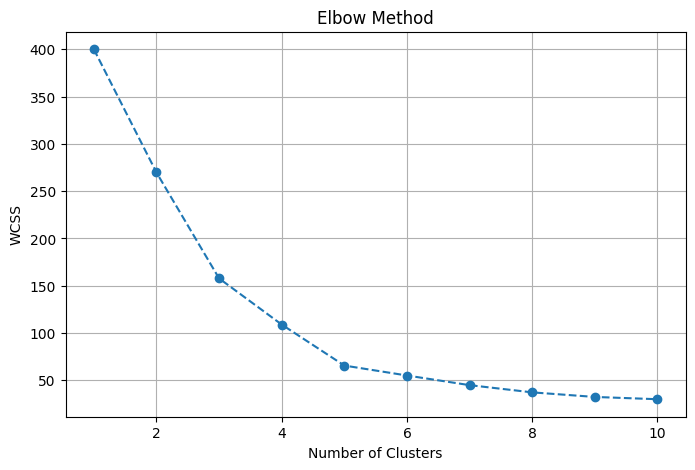

In [11]:
# Find WCSS for different cluster values
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [12]:
# Apply KMeans with optimal clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = y_kmeans

print("\nDataset with Cluster Labels:")
print(df.head())


Dataset with Cluster Labels:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [13]:
# Cluster centers in scaled form
print("\nCluster Centers (Scaled):")
print(kmeans.cluster_centers_)

# Convert cluster centers back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

print("\nCluster Centers (Original Scale):")
print(centers_original)


Cluster Centers (Scaled):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]

Cluster Centers (Original Scale):
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


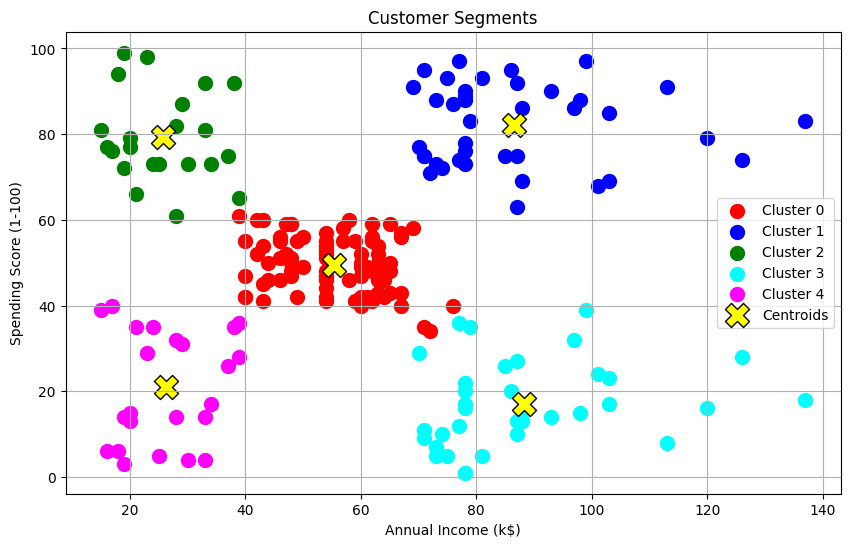

In [14]:
# Plot clusters
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(
        X.iloc[y_kmeans == i, 0],
        X.iloc[y_kmeans == i, 1],
        s=100,
        c=colors[i],
        label=f'Cluster {i}'
    )

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='yellow',
    label='Centroids',
    marker='X',
    edgecolors='black'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Count customers in each cluster
print("\nNumber of Customers in Each Cluster:")
print(df['Cluster'].value_counts().sort_index())


Number of Customers in Each Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_2520\3210112831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


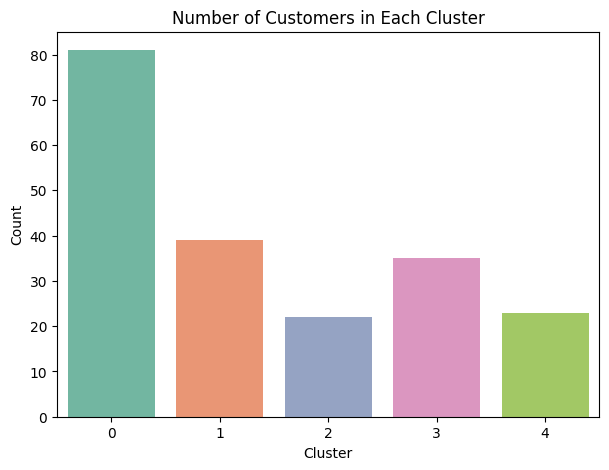

In [21]:
# Visualize number of customers in each cluster
plt.figure(figsize=(7,5))
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

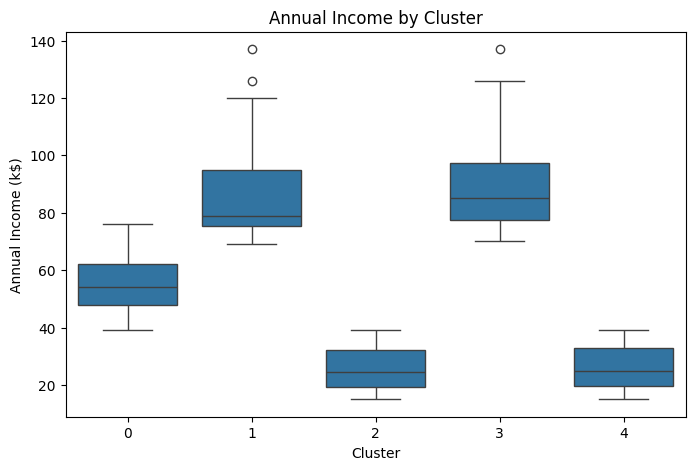

In [22]:
# Annual Income distribution by cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Annual Income (k$)', data=df)
plt.title("Annual Income by Cluster")
plt.show()

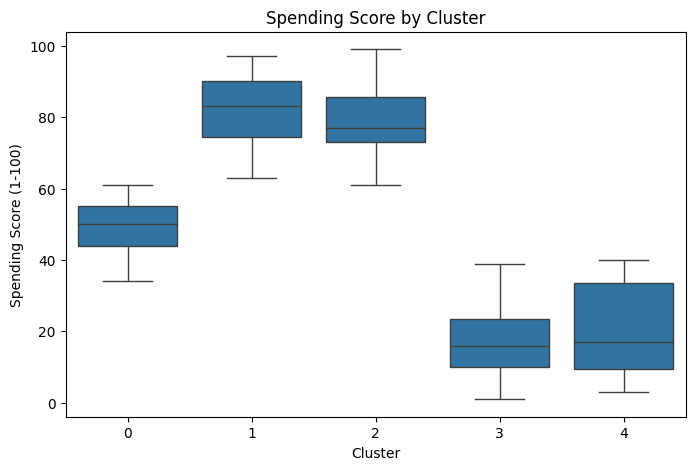

In [23]:
# Spending Score distribution by cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=df)
plt.title("Spending Score by Cluster")
plt.show()

In [24]:
# Add meaningful names to clusters
cluster_names = {
    0: "Standard Customers",
    1: "Careful Customers",
    2: "Target Customers",
    3: "Spending Customers",
    4: "Sensible Customers"
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print("\nCluster Names Added:")
print(df[['CustomerID', 'Cluster', 'Cluster_Name']].head())


Cluster Names Added:
   CustomerID  Cluster        Cluster_Name
0           1        4  Sensible Customers
1           2        2    Target Customers
2           3        4  Sensible Customers
3           4        2    Target Customers
4           5        4  Sensible Customers


In [25]:
# Save updated dataset
df.to_csv("Mall_Customers_Clustered_Final.csv", index=False)
print("\nFinal clustered dataset saved as 'Mall_Customers_Clustered_Final.csv'")


Final clustered dataset saved as 'Mall_Customers_Clustered_Final.csv'
